#### Importing Libraries

In [26]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm import tqdm
import torch.nn.functional as F

#### Root Data Directory Path

In [27]:
data_dir= r"C:\Projects_DS\signature_recognition\notebook\data"

#### Total Number Of Classes

In [28]:
class_name= os.listdir(data_dir)
len(class_name)

2

In [29]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T,datasets

#### Checking CUDA Availability

In [30]:
device= torch.device("cuda " if torch.cuda.is_available() else "cpu")
print("device:{}".format(device))

device:cpu


#### Transforming the Data

In [31]:
data_transform=T.Compose([
        T.Resize(size=(224,224)),
        T.RandomRotation(degrees=(-20,+20)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

In [32]:
data=datasets.ImageFolder(data_dir,transform=data_transform)
total_count=len(data)

In [33]:
total_count

2640

In [34]:
data.classes

['full_forg', 'full_org']

#### Splitting The Data

In [35]:
train_count=int(0.6*total_count)
valid_count=int(0.3*total_count)
test_count=total_count-train_count- valid_count
train_data,val_data,test_data =torch.utils.data.random_split(data, (train_count,valid_count,test_count))

In [36]:
len(train_data.indices)

1584

In [37]:
len(test_data.indices)

264

In [38]:
len(val_data.indices)

792

### Defining Some Functions

In [39]:
def show_image(image,label,get_denormalize=True):

    image=image.permute(1,2,0)
    mean=torch.FloatTensor([0.485,0.456,0.406])
    std=torch.FloatTensor([0.229,0.224,0.225])

    if get_denormalize == True:
        image=image*std +mean
        image=np.clip(image,0,1)
        plt.imshow(image)
        plt.title(label)
    else:
        plt.imshow(image)
        plt.title(label)

In [40]:
def accuracy(y_pred,y_true):
    y_pred=F.softmax(y_pred,dim=1)
    top_p,top_class=y_pred.topk(1,dim=1)
    equals=top_class==y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

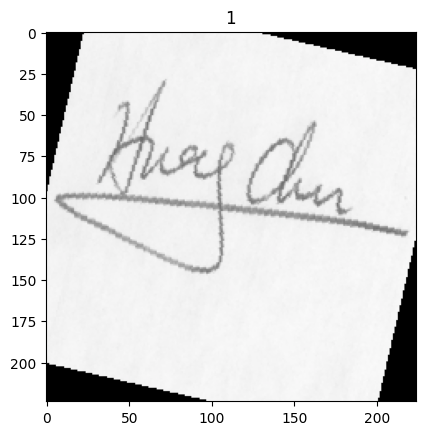

In [41]:
img,label=train_data[0]
show_image(img,label)

#### Data Loader

In [42]:
trainloader=DataLoader(train_data,batch_size=32,shuffle=True)
print("No. of batches in trainloader:{}".format(len(trainloader)))
print("No. of toal examples:{}",format(len(trainloader.dataset)))
validationloader=DataLoader(val_data,batch_size=32,shuffle=True)
print("No. of batches in validationloader:{}".format(len(validationloader)))
print("No. of toal examples:{}",format(len(validationloader.dataset)))
testloader=DataLoader(test_data,batch_size=32,shuffle=False)
print("No. of batches in testloader:{}".format(len(testloader)))
print("No. of toal examples:{}",format(len(testloader.dataset)))

No. of batches in trainloader:50
No. of toal examples:{} 1584
No. of batches in validationloader:25
No. of toal examples:{} 792
No. of batches in testloader:9
No. of toal examples:{} 264


#### Model

In [43]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [44]:
model= models.resnet34(pretrained=True)

In [45]:
model.fc= nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(model.fc.in_features,len(class_name))
)
model=model.to(device)
criterion= torch.nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(model.parameters(),lr=1e-3,momentum=0.9)

In [46]:
def train(model,criterion,optimizer,train_dataloader,test_dataloader):
    total_train_loss=0
    total_test_loss=0
    model.train()

    with tqdm(train_dataloader,unit='batch',leave=False) as pbar:
        pbar.set_description(f'training')
        for images, idxs in pbar:
            images = images.to(device,non_blocking=True)
            idxs = idxs.to(device,non_blocking=True)
            
            output= model(images)
            loss=criterion(output,idxs)
            total_train_loss+=loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    model.eval()
    with tqdm(test_dataloader,unit='batch',leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device,non_blocking=True)
            idxs = idxs.to(device,non_blocking=True)
            
            output= model(images)
            loss=criterion(output,idxs)
            total_test_loss+=loss.item()
            
    train_acc = total_train_loss/len(train_data)
    test_acc = total_test_loss/len(val_data)
    print(f'Train Loss: {train_acc :.4f} Test Loss:{test_acc:.4f}')

In [47]:
%%time
epochs =2
for i in range (epochs):
    print(f"Epochs{i+1}")
    train(model,criterion,optimizer,trainloader,validationloader)


Epochs1


Train Loss: 0.0085 Test Loss:0.0361
Epochs2


Train Loss: 0.0012 Test Loss:0.0003
CPU times: total: 1h 7min 49s
Wall time: 9min 34s


#### Model Saving

In [51]:
Path =r'C:\\Projects_DS\\signature_recognition\\notebook\\model.pt'
torch.save(model,Path)

#### Loading Torch Model

In [55]:
model= torch.load(Path, weights_only=False)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Model Evaluation

In [60]:
def evaluate (model,criterion,optimizer,test_dataloader):
    total_test_loss=0

    model.eval()
    with tqdm (test_dataloader,unit='batch',leave=False) as pbar:
        pbar.set_description(f'testing')
        for images,idxs in pbar:
            images= images.to(device,non_blocking=True)
            idxs =idxs.to(device,non_blocking= True)

            output=model(images)
            loss=criterion(output,idxs)
            total_test_loss+=loss.item()

    test_acc=total_test_loss/len(val_data)
    print(f'test loss:{test_acc:.4f}')

In [61]:
evaluate(model,criterion,optimizer,testloader)

test loss:0.0001


#### Prediction


In [62]:
label_names= data.classes
label_names

['full_forg', 'full_org']

In [87]:
from PIL import Image
#load the image and preprocess it 
image=Image.open(r'C:\Projects_DS\signature_recognition\notebook\data\full_org\original_2_5.png')
preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3), 
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
image= preprocess(image)
image=image[:3]

#convert image to pytorch tensor
image=image.unsqueeze(0).to(device)

#make the prediction
with torch.no_grad():
    logits= model(image)
    probs = torch.softmax(logits,dim=1)
    pred_label = torch.argmax(probs,dim=1)

#print the prediction
print(f'Predicted Label: {pred_label.item()}')

#Map the predicted label to Corresponding class name
predicted_class_name= label_names[pred_label.item()]
#print the predicted class name
print(f'Predicted Class name: {predicted_class_name}')

Predicted Label: 1
Predicted Class name: full_org


In [88]:
print(probs)

tensor([[0.0068, 0.9932]])
